## 1. Data Loading and Environment Setup

First, we need to import the essential data science libraries (`pandas`, `seaborn`, `matplotlib`) and load the IBM HR Analytics dataset. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set scannable and clean visualization style for Notion
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = [10, 6]

# Load the dataset using raw string path
file_path = r'D:\DA-project-02-HR Analytics\DA-project-02-HR-Analytics\data\WA_Fn-UseC_-HR-Employee-Attrition.csv'
df = pd.read_csv(file_path)

# Quick sanity check
print(f"Dataset successfully loaded. Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")

Dataset successfully loaded. Total Rows: 1470, Total Columns: 35


## 2. Defining "Top Talent" (High Performers Segmentation)

Instead of analyzing the overall workforce average, this project zeroes in on **"The Brain Drain"** phenomenon. We define our **"Top Talent"** segment based on two aggressive performance metrics:
1. High performance evaluation (`PerformanceRating == 4`)
2. Outstanding merit recognition (`PercentSalaryHike >= 15`)

By filtering the data this way, we can isolate the behaviors and pain points of our most valuable assets.

### ⚠️ Methodological Considerations & Constraints:
* **Strict Filtering (AND Logic):** By applying both conditions, we isolate the "absolute elite." However, this might exclude high-performing individuals who suffered from departmental budget constraints (hence a lower salary hike despite a rating of 4).
* **The "HiPo" (High Potential) Factor:** Future iterations could benefit from including employees with rapid promotion tracks (`YearsSinceLastPromotion == 0` combined with high satisfaction), even if their salary hike hasn't caught up yet.

In [7]:
# Filter for Top Talent
top_talent_df = df[(df['PerformanceRating'] == 4) | (df['PercentSalaryHike'] >= 15)].copy()

# Calculate the proportion of Top Talent in the company
total_employees = len(df)
total_top_talent = len(top_talent_df)
top_talent_ratio = (total_top_talent / total_employees) * 100

print(f"Total Employees: {total_employees}")
print(f"Total Top Talent identified: {total_top_talent} ({top_talent_ratio:.2f}% of workforce)")

Total Employees: 1470
Total Top Talent identified: 652 (44.35% of workforce)


## 3. The Baseline: What is the Attrition Rate among Top Talent?

Before digging into the root causes, we need to establish the baseline. What percentage of our high performers are actually walking out the door? In HR standards, losing more than 10% of high performers annually is considered a critical risk.

--- Top Talent Attrition Breakdown ---
No: 83.90% (547 employees)
Yes: 16.10% (105 employees)


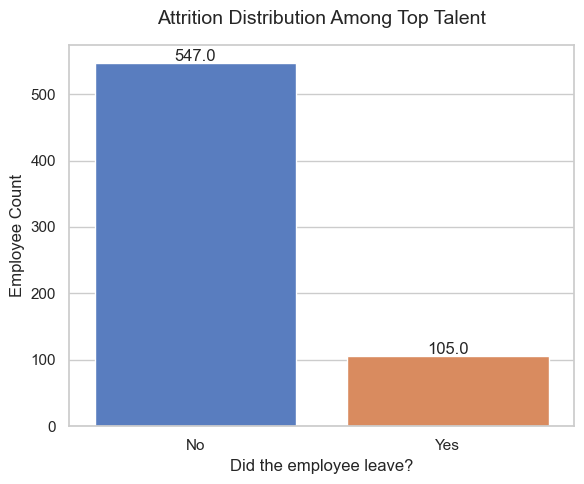

In [5]:
# Calculate Attrition proportions for Top Talent
attrition_counts = top_talent_df['Attrition'].value_counts()
attrition_percentages = top_talent_df['Attrition'].value_counts(normalize=True) * 100

print("--- Top Talent Attrition Breakdown ---")
for index, value in attrition_percentages.items():
    print(f"{index}: {value:.2f}% ({attrition_counts[index]} employees)")

# Plotting the Baseline Attrition
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=top_talent_df, x='Attrition', hue='Attrition', legend=False)
plt.title('Attrition Distribution Among Top Talent', fontsize=14, pad=15)
plt.xlabel('Did the employee leave?', fontsize=12)
plt.ylabel('Employee Count', fontsize=12)

# Add value labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

## 4. Deep Dive 1: Is Overtime Driving Burnout in Our Top Talent?

A common corporate trap is assigning the heaviest workload to the most capable people. Let's analyze how mandatory Overtime affects the attrition rate specifically within our high-performing segment.

--- Overtime vs Attrition Matrix (% by Row) ---
Attrition     No    Yes
OverTime               
No         89.31  10.69
Yes        69.14  30.86


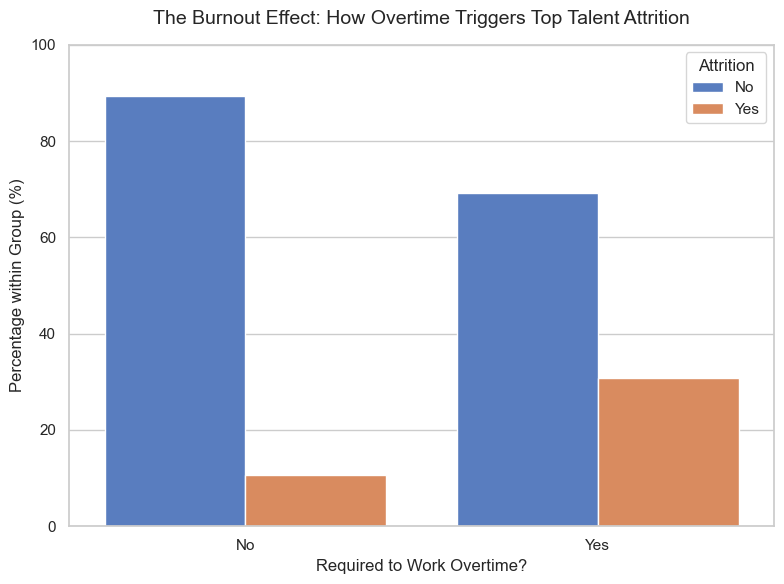

In [6]:
# Cross-tabulate OverTime vs Attrition for Top Talent
ot_attrition_matrix = pd.crosstab(top_talent_df['OverTime'], top_talent_df['Attrition'], normalize='index') * 100

print("--- Overtime vs Attrition Matrix (% by Row) ---")
print(ot_attrition_matrix.round(2))

# Reshape data for plotting
plot_data = top_talent_df.groupby(['OverTime', 'Attrition']).size().reset_index(name='Count')
# Calculate percentages within each OverTime group
plot_data['Percentage'] = plot_data.groupby('OverTime')['Count'].transform(lambda x: (x / x.sum()) * 100)

# Plotting Overtime Impact
plt.figure(figsize=(8, 6))
sns.barplot(data=plot_data, x='OverTime', y='Percentage', hue='Attrition')
plt.title('The Burnout Effect: How Overtime Triggers Top Talent Attrition', fontsize=14, pad=15)
plt.xlabel('Required to Work Overtime?', fontsize=12)
plt.ylabel('Percentage within Group (%)', fontsize=12)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

# Executive Summary: Top Talent & Attrition Analysis

## 1. Overview and Baseline Attrition Risk
* **High Density of Top Talent:** Out of 1,470 total employees, 652 individuals are identified as **Top Talent**, accounting for **44.35%** of the entire workforce[cite: 1].
* **Critical Attrition Rate:** The attrition rate within this elite group stands at **16.10% (105 employees)**[cite: 1]. In HR analytics, losing more than 10% of high-potential employees annually is flagged as a **Critical Risk** that demands immediate intervention[cite: 1].

---

## 2. The Overtime Burnout Trap
A deep dive into the work habits of Top Talent reveals a strong correlation between **Overtime (OT)** and their decision to leave the company[cite: 1].

| Overtime Status | Stay Rate (No Attrition) | Attrition Rate (Left) |
| :--- | :---: | :---: |
| **No Overtime** | 89.31% | **10.69%** |
| **With Overtime** | 69.14% | **30.86%** |

### Key Findings:
* **Overtime Triples Attrition Risk:** Top Talent required to work overtime exhibits an alarming attrition rate of **30.86%**—nearly **three times higher** than those who do not work overtime (10.69%)[cite: 1].
* **The Safe Zone:** When overtime is eliminated, the attrition rate drops back to a manageable baseline of 10.69%, which aligns with standard healthy turnover rates[cite: 1].

---

> 💡 **Core Strategic Insight**
> The data highlights a classic corporate pitfall: **"Punishing the competent with more work."** Because these employees perform exceptionally well, they are frequently assigned heavy workloads and critical projects that require overtime[cite: 1]. This directly accelerates burnout, causing nearly **1 in 3 top-tier employees** to walk out the door[cite: 1]. Mitigating overtime and restructuring workload distribution is the most critical lever for retaining the company's most valuable assets[cite: 1].